# **Evaluation Notebook**

### **Wikiart Project**

**Group 22:**\
**Afonso Hermenegildo** - 20221958 | **Lara Santos** - 20221823 | **Marco Martins** - 20221951 | **André Nicolau** - 20221918 | **André Ferreira** - 20250398

Github repository: https://github.com/MarcoAFMartins/Wikiart_Project

---

# Table of Contents

1. [Classification report (accuracy, macro-F1, per-class precision/recall)](#section-1)  
2. [Confusion matrix (seaborn heatmap)](#section-2)  
3. [Training curves (loss & accuracy)](#section-3)  
4. [Grad-CAM visualisation](#section-4)  
5. [Misclassified samples analysis](#section-5)
6. [Model comparison table](#section-5)

---

# Imports

In [1]:
import sys
sys.path.append('../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

import keras
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import image_dataset_from_directory
from base_model_class import BatchNormalization2_Model

2026-04-24 15:08:54.679991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777039734.707989    2256 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777039734.718278    2256 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777039734.815662    2256 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777039734.815741    2256 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777039734.815743    2256 computation_placer.cc:177] computation placer alr

# Load dataset and model

In [2]:
OUTPUTS_DIR = "../outputs"
FIGURES_DIR = OUTPUTS_DIR + "/figures"

TEST_PATH = "../clean_split_data/test"

MODEL_PATH = OUTPUTS_DIR + "/models/base_model.keras"

IMAGE_SIZE = (128, 128)
INPUT_SHAPE = IMAGE_SIZE + (3,)
BATCH_SIZE = 64

In [3]:
test_ds = image_dataset_from_directory(
    TEST_PATH,
    label_mode="categorical",
    interpolation="bilinear",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=42,
    shuffle=True # for the base model we were having issues using shuffle=False, getting wrong scores, likely due to BatchNormalization layer
)

class_names = test_ds.class_names
print(f"Classes: {len(class_names)} — {class_names}")

Found 2000 files belonging to 23 classes.
Classes: 23 — ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [4]:
model: BatchNormalization2_Model  = BatchNormalization2_Model()
model = keras.models.load_model(MODEL_PATH)
print(f'Model loaded from: {MODEL_PATH}')

Model loaded from: ../outputs/models/base_model.keras


In [5]:
model.summary()

Model: "BatchNormalization_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ ?                      │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 124, 124, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 124, 124, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 62, 62, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 62, 62, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 31, 31, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,32

 Total params: 254,911 (995.75 KB)

 Trainable params: 84,831 (331.37 KB)

 Non-trainable params: 416 (1.62 KB)

 Optimizer params: 169,664 (662.75 KB)

# Make predictions

In [6]:
y_true, y_pred, y_prob = [], [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

I0000 00:00:1777039744.977633    2412 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-24 15:09:11.840897: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
model.evaluate(test_ds)

2026-04-24 15:09:13.582368: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.44GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5165 - auc: 0.9235 - f1_score: 0.4772 - loss: 1.6438


[1.6437764167785645,
 0.5164999961853027,
 0.9235319495201111,
 0.47720012068748474]

# Classification Report

## 4. Classification report
> Primary metric for this project is **macro-F1** because classes may be imbalanced.
> Macro-F1 gives equal weight to all classes regardless of size.
> If macro-F1 is much lower than accuracy, the model is biased toward majority classes.

In [8]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save as file for the report
with open(OUTPUTS_DIR + "/classification_report.txt", "w") as f:
    f.write(report)
print('Saved!')

                       precision    recall  f1-score   support

       Albrecht_Durer       0.56      0.37      0.44        87
      Boris_Kustodiev       0.41      0.25      0.31        67
     Camille_Pissarro       0.38      0.41      0.40        93
        Childe_Hassam       0.46      0.19      0.27        57
         Claude_Monet       0.47      0.66      0.55       140
          Edgar_Degas       0.36      0.28      0.32        64
        Eugene_Boudin       0.60      0.50      0.55        58
         Gustave_Dore       0.75      0.91      0.82        80
           Ilya_Repin       0.47      0.39      0.43        56
      Ivan_Aivazovsky       0.85      0.68      0.76        60
        Ivan_Shishkin       0.58      0.48      0.53        54
  John_Singer_Sargent       0.48      0.37      0.42        83
         Marc_Chagall       0.35      0.22      0.27        81
      Martiros_Saryan       0.26      0.23      0.24        61
     Nicholas_Roerich       0.60      0.70      0.65  

## 5. Confusion matrix
> The diagonal = correct predictions. Off-diagonal = errors.
> Look for clusters of errors between visually similar classes.

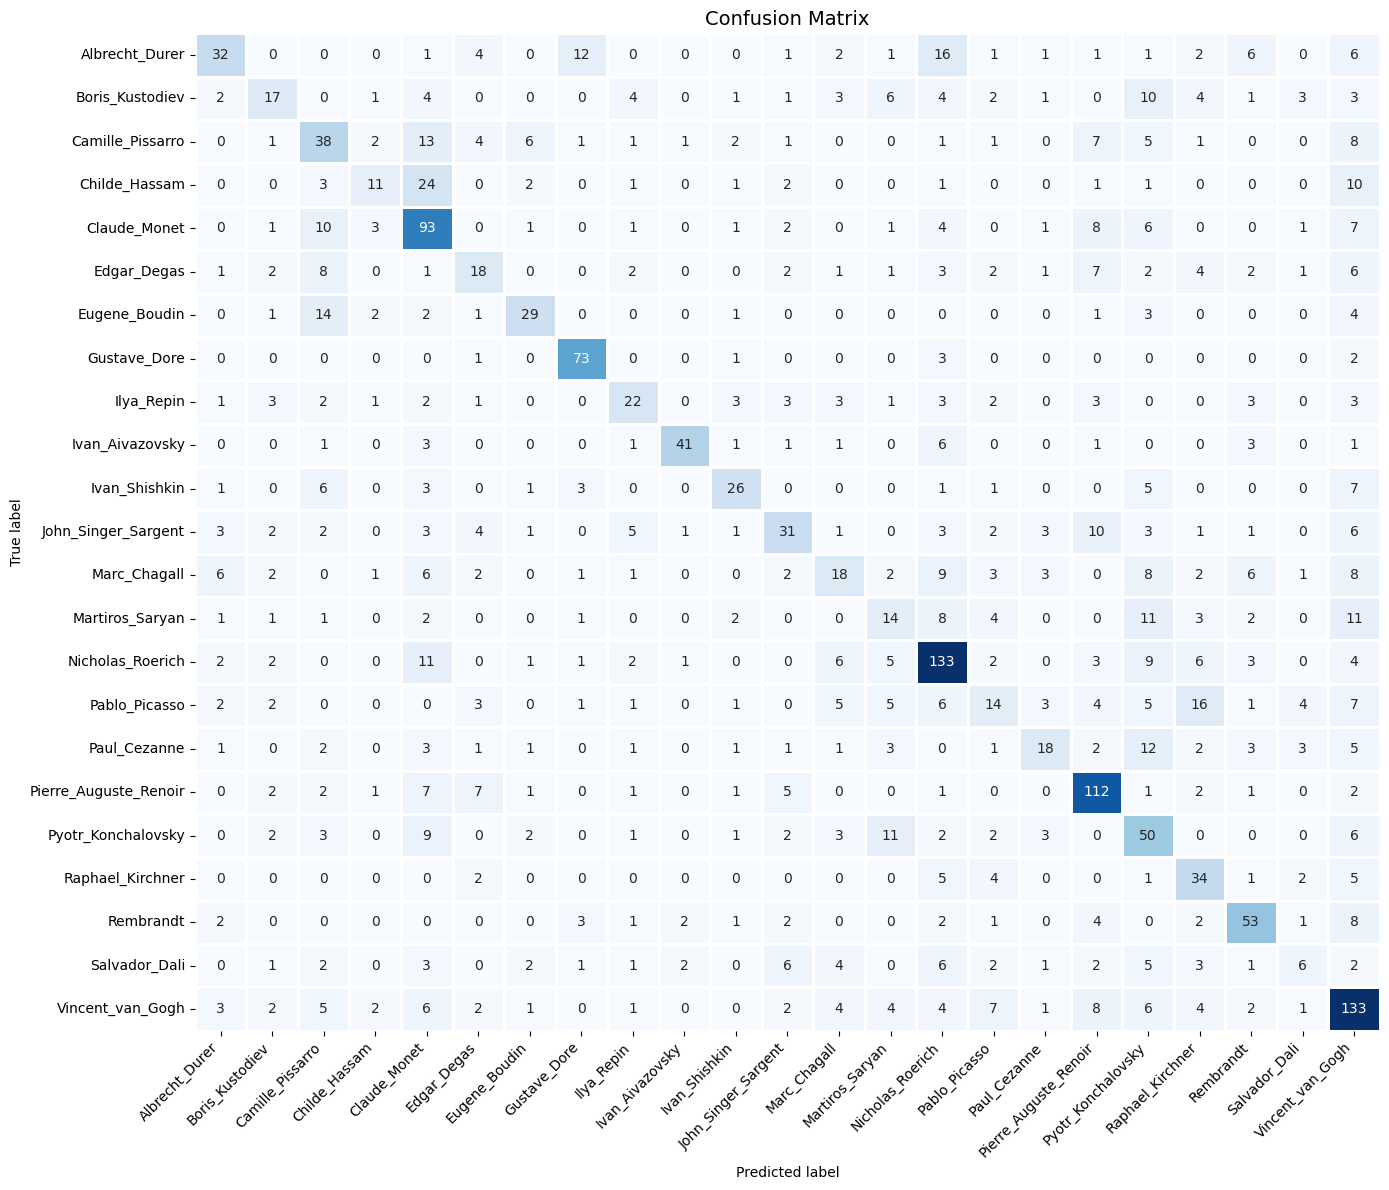


Per-class accuracy:
  Albrecht_Durer                 0.368
  Boris_Kustodiev                0.254
  Camille_Pissarro               0.409
  Childe_Hassam                  0.193
  Claude_Monet                   0.664
  Edgar_Degas                    0.281
  Eugene_Boudin                  0.500
  Gustave_Dore                   0.912
  Ilya_Repin                     0.393
  Ivan_Aivazovsky                0.683
  Ivan_Shishkin                  0.481
  John_Singer_Sargent            0.373
  Marc_Chagall                   0.222
  Martiros_Saryan                0.230
  Nicholas_Roerich               0.696
  Pablo_Picasso                  0.175
  Paul_Cezanne                   0.295
  Pierre_Auguste_Renoir          0.767
  Pyotr_Konchalovsky             0.515
  Raphael_Kirchner               0.630
  Rembrandt                      0.646
  Salvador_Dali                  0.120
  Vincent_van_Gogh               0.672


In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=1,
    cbar=False,
    annot_kws={'fontsize': 10},
    yticklabels=class_names,
    xticklabels=class_names,
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# save figure for the report
plt.savefig(FIGURES_DIR + "/confusion_matrix.png", dpi=150)
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    per_class_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f'  {name:<30} {per_class_acc:.3f}')

## 7. Grad-CAM
> Visualises which regions of the painting the model focuses on.
> Reference: https://keras.io/examples/vision/grad_cam/
> For VGG16, the last conv layer is `block5_conv3`.

In [10]:
inputs = keras.Input(shape=INPUT_SHAPE)

x = model.Rescaling(inputs)
        
x = model.augmentation_layer(x)

x = model.Conv1(x)
x = model.BatchNormalization_layer1(x)
x = model.activation_1(x)
x = model.max_pool_layer_1(x)

x = model.Conv2(x)
x = model.BatchNormalization_layer2(x)
x = model.activation_2(x)
x = model.max_pool_layer_2(x)

x = model.Conv3(x)
x = model.BatchNormalization_layer3(x)
x = model.activation_3(x)
x = model.max_pool_layer_3(x)

convolutions_output = model.Conv4(x)
x = model.BatchNormalization_layer4(convolutions_output)
x = model.activation_4(x)
x = model.max_pool_layer_4(x)

x = model.Globalaveragepooling_layer(x)
x = model.Dense_1(x)
x = model.Drop_out(x)
outputs = model.Dense_2(x)

grad_model = keras.Model(inputs=inputs, outputs=[convolutions_output, outputs])

2026-04-24 15:09:22.789342: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


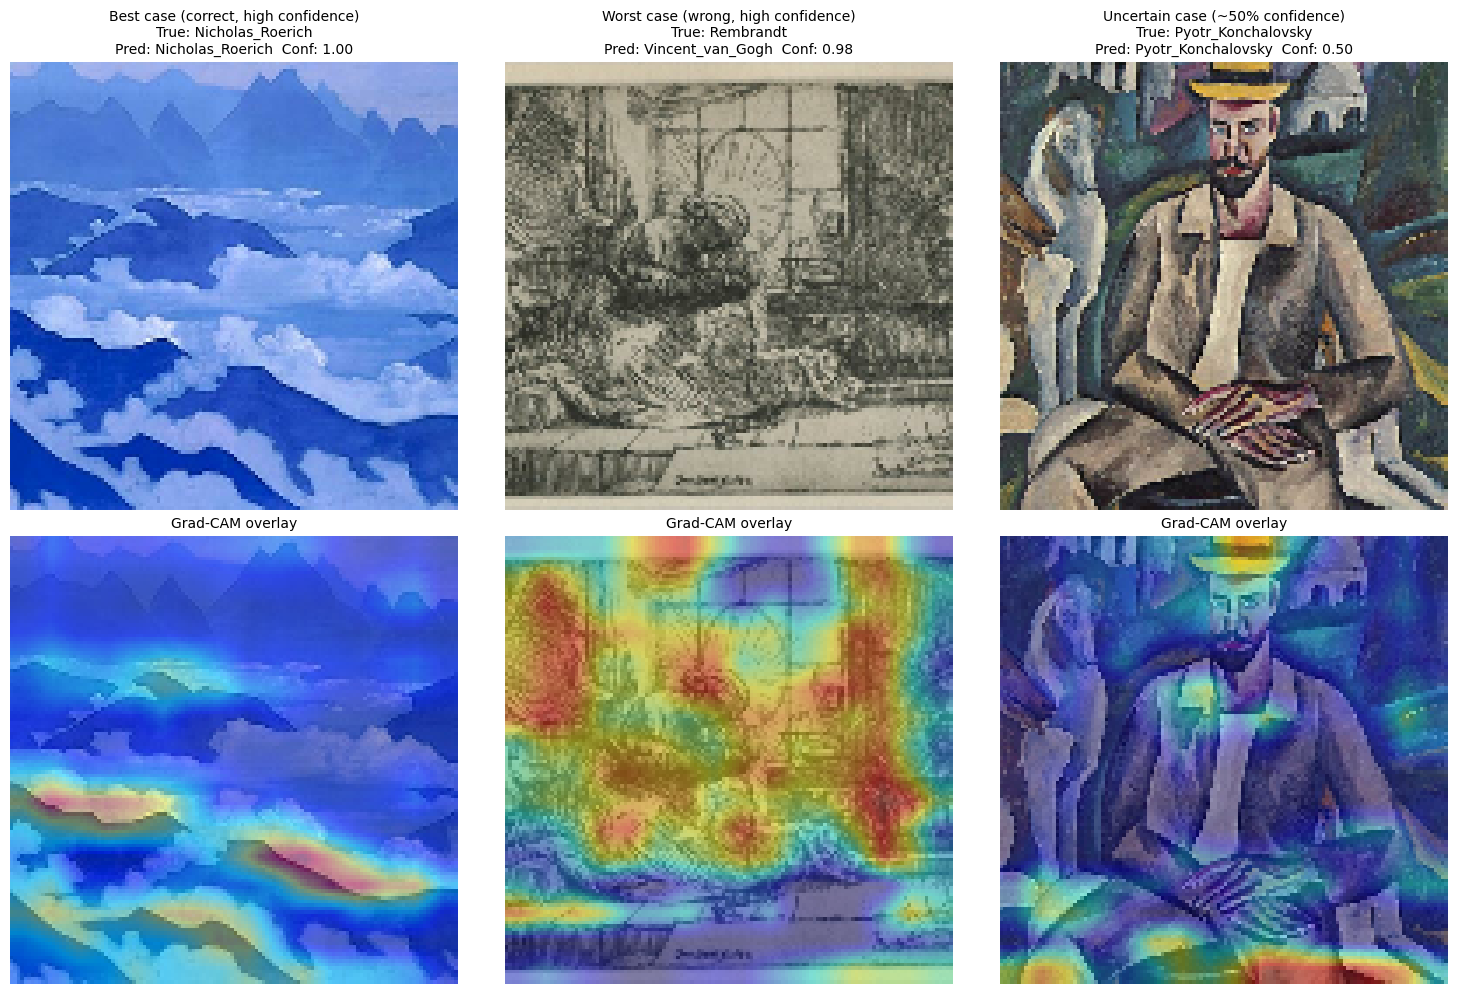

In [11]:
# Collect all test images with predictions and confidences in one pass
# (self-contained so we don't rely on ordering from earlier prediction loops)
all_images_list, all_true_list, all_pred_list, all_conf_list = [], [], [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    trues = np.argmax(labels.numpy(), axis=1)
    confs = probs[np.arange(len(preds)), preds]

    all_images_list.append(images.numpy())
    all_true_list.append(trues)
    all_pred_list.append(preds)
    all_conf_list.append(confs)

all_images = np.concatenate(all_images_list, axis=0)
all_true = np.concatenate(all_true_list, axis=0)
all_pred = np.concatenate(all_pred_list, axis=0)
all_conf = np.concatenate(all_conf_list, axis=0)

# 1. Best case: correct prediction with highest confidence
correct_mask = (all_pred == all_true)
best_idx = int(np.where(correct_mask)[0][np.argmax(all_conf[correct_mask])])

# 2. Worst case: wrong prediction with highest confidence
wrong_mask = (all_pred != all_true)
worst_idx = int(np.where(wrong_mask)[0][np.argmax(all_conf[wrong_mask])])

# 3. Uncertain case: confidence closest to 0.5
uncertain_idx = int(np.argmin(np.abs(all_conf - 0.5)))

selected_indices = [best_idx, worst_idx, uncertain_idx]
case_titles = [
    "Best case (correct, high confidence)",
    "Worst case (wrong, high confidence)",
    "Uncertain case (~50% confidence)",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, (idx, case_title) in enumerate(zip(selected_indices, case_titles)):
    img = all_images[idx]
    img_np = img.astype("uint8")
    img_batch = tf.expand_dims(tf.convert_to_tensor(img), axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch, training=False)
        tape.watch(conv_outputs)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_res = cv2.resize(heatmap, (128, 128))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

    true_class = class_names[all_true[idx]]
    pred_class = class_names[all_pred[idx]]
    confidence = all_conf[idx]

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(
        f"{case_title}\nTrue: {true_class}\nPred: {pred_class}  Conf: {confidence:.2f}",
        fontsize=10,
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay)
    axes[1, col].set_title("Grad-CAM overlay", fontsize=10)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## 8. Misclassified samples
> Show the worst predictions — highest confidence but wrong.
> Ask: are these images ambiguous? Similar to another class? Possibly mislabelled?

Total misclassified: 975 / 2000 (48.8%)


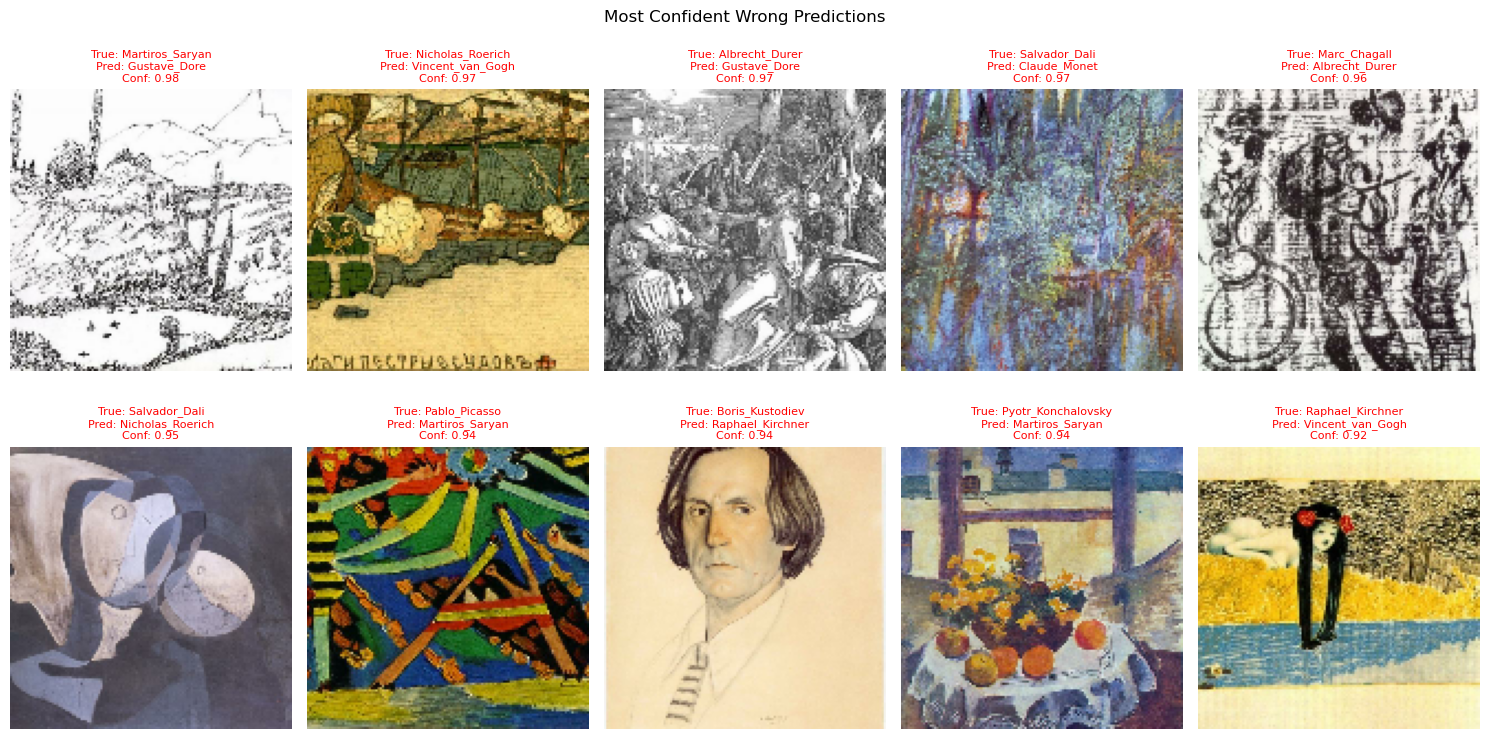

In [12]:
# Collect all misclassified images with their confidence
wrong_imgs, wrong_true, wrong_pred, wrong_conf = [], [], [], []

for images, labels in test_ds:
    probs        = model.predict(images, verbose=0)
    pred_classes = np.argmax(probs, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    for i in range(len(true_classes)):
        if pred_classes[i] != true_classes[i]:
            wrong_imgs.append(images[i].numpy().astype('uint8'))
            wrong_true.append(true_classes[i])
            wrong_pred.append(pred_classes[i])
            wrong_conf.append(probs[i][pred_classes[i]])   # confidence of wrong prediction

# Sort by highest confidence wrong prediction (worst mistakes)
sorted_idx  = np.argsort(wrong_conf)[::-1]
n_show      = min(10, len(sorted_idx))

print(f'Total misclassified: {len(wrong_imgs)} / {len(y_true)} ({len(wrong_imgs)/len(y_true)*100:.1f}%)')

cols = 5
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, idx in enumerate(sorted_idx[:n_show]):
    axes[i].imshow(wrong_imgs[idx])
    axes[i].set_title(
        f'True: {class_names[wrong_true[idx]]}\nPred: {class_names[wrong_pred[idx]]}\nConf: {wrong_conf[idx]:.2f}',
        fontsize=8, color='red'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Most Confident Wrong Predictions', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR + "/misclassified.png", dpi=150)
plt.show()

In [13]:
print(f"{'Class Name':<30} | {'Total Errors'}")
print("-" * 45)

for i, name in enumerate(class_names):
    # Total images in this class minus the ones on the diagonal (correct)
    total_in_class = cm[i].sum()
    correct_preds = cm[i, i]
    errors = total_in_class - correct_preds
    
    print(f"{name:<30} | {int(errors)}")

Class Name                     | Total Errors
---------------------------------------------
Albrecht_Durer                 | 55
Boris_Kustodiev                | 50
Camille_Pissarro               | 55
Childe_Hassam                  | 46
Claude_Monet                   | 47
Edgar_Degas                    | 46
Eugene_Boudin                  | 29
Gustave_Dore                   | 7
Ilya_Repin                     | 34
Ivan_Aivazovsky                | 19
Ivan_Shishkin                  | 28
John_Singer_Sargent            | 52
Marc_Chagall                   | 63
Martiros_Saryan                | 47
Nicholas_Roerich               | 58
Pablo_Picasso                  | 66
Paul_Cezanne                   | 43
Pierre_Auguste_Renoir          | 34
Pyotr_Konchalovsky             | 47
Raphael_Kirchner               | 20
Rembrandt                      | 29
Salvador_Dali                  | 44
Vincent_van_Gogh               | 65


/tmp/ipykernel_2256/4229244117.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Errors', y='Artist', data=error_val_df, palette='Reds_r')


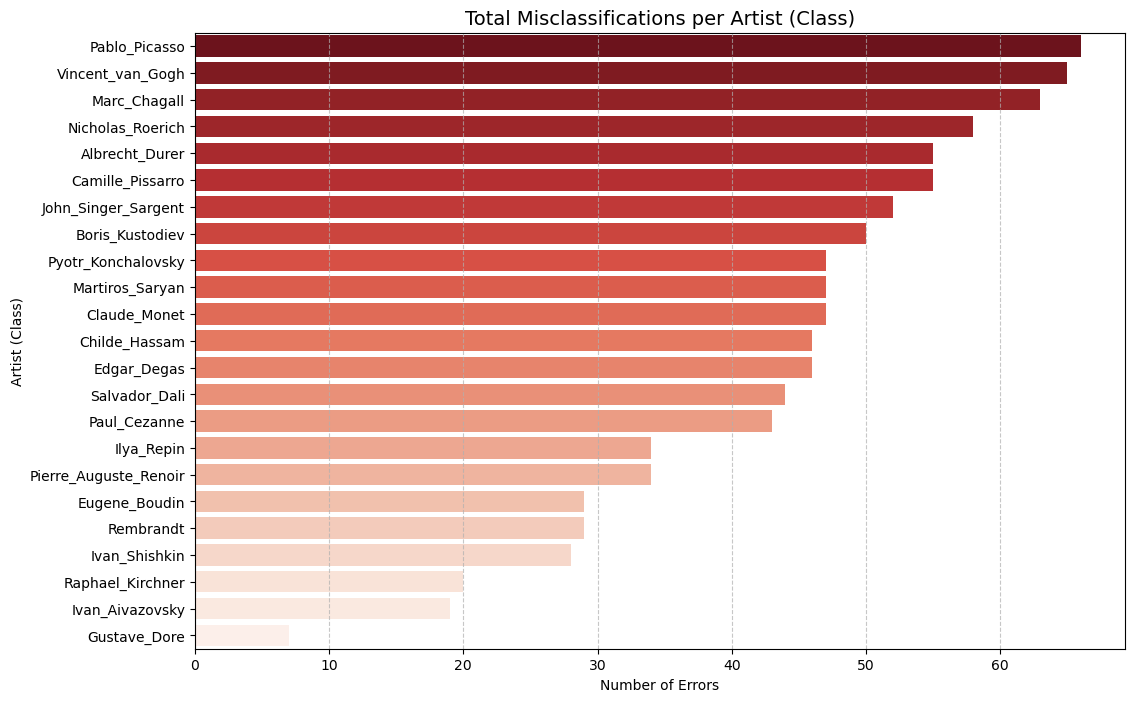

In [14]:
# Calculate error counts
error_counts = []
for i in range(len(class_names)):
    error_counts.append(cm[i].sum() - cm[i, i]) #cm is the confusion matrix

# Sort by error count
error_val_df = pd.DataFrame({'Artist': class_names, 'Errors': error_counts})
error_val_df = error_val_df.sort_values('Errors', ascending=False)

# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Errors', y='Artist', data=error_val_df, palette='Reds_r') 

plt.title('Total Misclassifications per Artist (Class)', fontsize=14)
plt.xlabel('Number of Errors')
plt.ylabel('Artist (Class)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save for your project folder
plt.savefig(FIGURES_DIR + '/errors_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2256/1188436745.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=error_df, x='Error %', y='Artists (Class)', palette='magma')


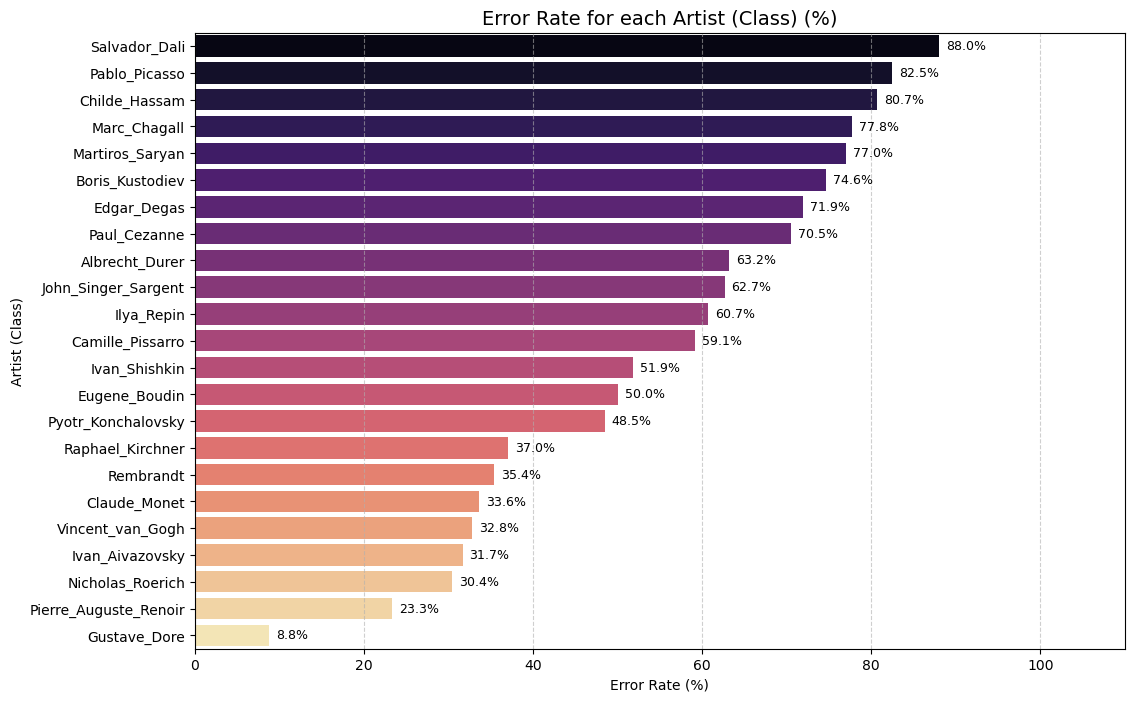

In [15]:
# percentage of errors for each class

per_class_error_pct = []

for i in range(len(class_names)):
    total_samples = cm[i].sum()
    if total_samples > 0:
        # (Total images - correct predictions / total images) * 100
        error_pct = (1 - (cm[i,i]) / total_samples) * 100
        per_class_error_pct.append(error_pct)
    else:
        per_class_error_pct.append(0)

# Save as DataFrame to ease the visualization

error_df = pd.DataFrame({
    'Artists (Class)': class_names,
    'Error %': per_class_error_pct
}).sort_values('Error %', ascending=False) # Order by the classes with the bigger % of error

# Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=error_df, x='Error %', y='Artists (Class)', palette='magma')

# To appear the % on the bars. 
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', 
                va='center', fontsize=9)

plt.title('Error Rate for each Artist (Class) (%)', fontsize=14)
plt.xlabel('Error Rate (%)')
plt.ylabel('Artist (Class)')
plt.xlim(0, 110) # text
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.savefig(FIGURES_DIR + '/error_percentage_by_class.png', dpi=150, bbox_inches='tight')
plt.show()